In [ ]:
# NB! If you plan to run the full notebook, incl creating the embeddings for the dataset and performing grid search for BERTopic, it is highly recommended to connect to GPU runtime

In [ ]:
# Make sure to download the requirements file and upload it before executing

!pip install -r /content/requirements.txt

In [ ]:
import scikit-learn as sklearn
from sklearn.metrics import normalized_mutual_info_score as NMI
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
    fowlkes_mallows_score
)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
from bertopic import BERTopic
from hdbscan import HDBSCAN
import seaborn as sns
from umap import UMAP
import pandas as pd
import numpy as np
import torch
import json
import math
import os
import re
import gc

**1. Load & Explore the Dataset**

In [ ]:
os.environ['KAGGLE_USERNAME'] = "INSERT YOUR KAGGLE USERNAME"
os.environ['KAGGLE_KEY'] = "INSERT YOUR KAGGLE API KEY"

In [ ]:
username = os.environ.get("KAGGLE_USERNAME")
key = os.environ.get("KAGGLE_KEY")

if username is None or key is None:
    raise ValueError("Please set KAGGLE_USERNAME and KAGGLE_KEY as environment variables.")

In [ ]:
# Download the dataset
!kaggle datasets download -d Cornell-University/arxiv

Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
arxiv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Unzip the file
!unzip arxiv.zip

Archive:  arxiv.zip
replace arxiv-metadata-oai-snapshot.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
# Get a list of dicts and convert into a pandas df
# Preserving the first 100K entries only, to speed up execution of this demo
arxiv_data = []

with open("arxiv-metadata-oai-snapshot.json", "r") as f:
    for i, line in enumerate(f):
      if i >= 100000:
        break
      record = json.loads(line)
      if record.get('abstract') and record.get('categories'):
            # keep only abstract and categories to avoid OOM issues
          arxiv_data.append({
                'abstract': record['abstract'],
                'categories': record['categories']
            })

df = pd.DataFrame(arxiv_data)

In [ ]:
print(df[:10])

                                            abstract         categories
0    A fully differential calculation in perturba...             hep-ph
1    We describe a new algorithm, the $(k,\ell)$-...      math.CO cs.CG
2    The evolution of Earth-Moon system is descri...     physics.gen-ph
3    We show that a determinant of Stirling cycle...            math.CO
4    In this paper we show how to compute the $\L...    math.CA math.FA
5    We study the two-particle wave function of p...  cond-mat.mes-hall
6    A rather non-standard quantum representation...              gr-qc
7    A general formulation was developed to repre...  cond-mat.mtrl-sci
8    We discuss the results from the combined IRA...           astro-ph
9    Partial cubes are isometric subgraphs of hyp...            math.CO


In [ ]:
# Establish the primary_category - first mentioned & without subcategorization

df['primary_category'] = df['categories'].apply(lambda x: x.split()[0].split('.')[0])

In [ ]:
print(df[:10])

                                            abstract         categories  \
0    A fully differential calculation in perturba...             hep-ph   
1    We describe a new algorithm, the $(k,\ell)$-...      math.CO cs.CG   
2    The evolution of Earth-Moon system is descri...     physics.gen-ph   
3    We show that a determinant of Stirling cycle...            math.CO   
4    In this paper we show how to compute the $\L...    math.CA math.FA   
5    We study the two-particle wave function of p...  cond-mat.mes-hall   
6    A rather non-standard quantum representation...              gr-qc   
7    A general formulation was developed to repre...  cond-mat.mtrl-sci   
8    We discuss the results from the combined IRA...           astro-ph   
9    Partial cubes are isometric subgraphs of hyp...            math.CO   

  primary_category  
0           hep-ph  
1             math  
2          physics  
3             math  
4             math  
5         cond-mat  
6            gr-qc  
7     

In [ ]:
# General dataset features

print(f"Total number of papers: {len(df)}")
print(f"Number of unique primary categories: {df['primary_category'].nunique()}")
print(f"Number of unique full categories: {df['categories'].nunique()}")

Total number of papers: 100000
Number of unique primary categories: 18
Number of unique full categories: 6072


In [ ]:
# Explore abstract lengths to decide on preprocessing strategy

abstract_lengths = df['abstract'].apply(lambda x: len(x.split()))

avg_len = abstract_lengths.mean()
min_len = abstract_lengths.min()
max_len = abstract_lengths.max()

print(f"Average abstract length: {avg_len:.1f} words")
print(f"Minimum abstract length: {min_len} words")
print(f"Maximum abstract length: {max_len} words")

Average abstract length: 121.0 words
Minimum abstract length: 2 words
Maximum abstract length: 457 words


In [ ]:
# We found outliers with abstract length of few words, which means
#   dataset cleaning and preprocessing must include
#   removing entries with uninformatively short abstracts.
# The avg abstract length was found to be reasonable (121 words), as is the
#   maximum abstract length (457 words), enabling encoding abstracts with SBERT #   within the token limit without any abstract trimming necessary.

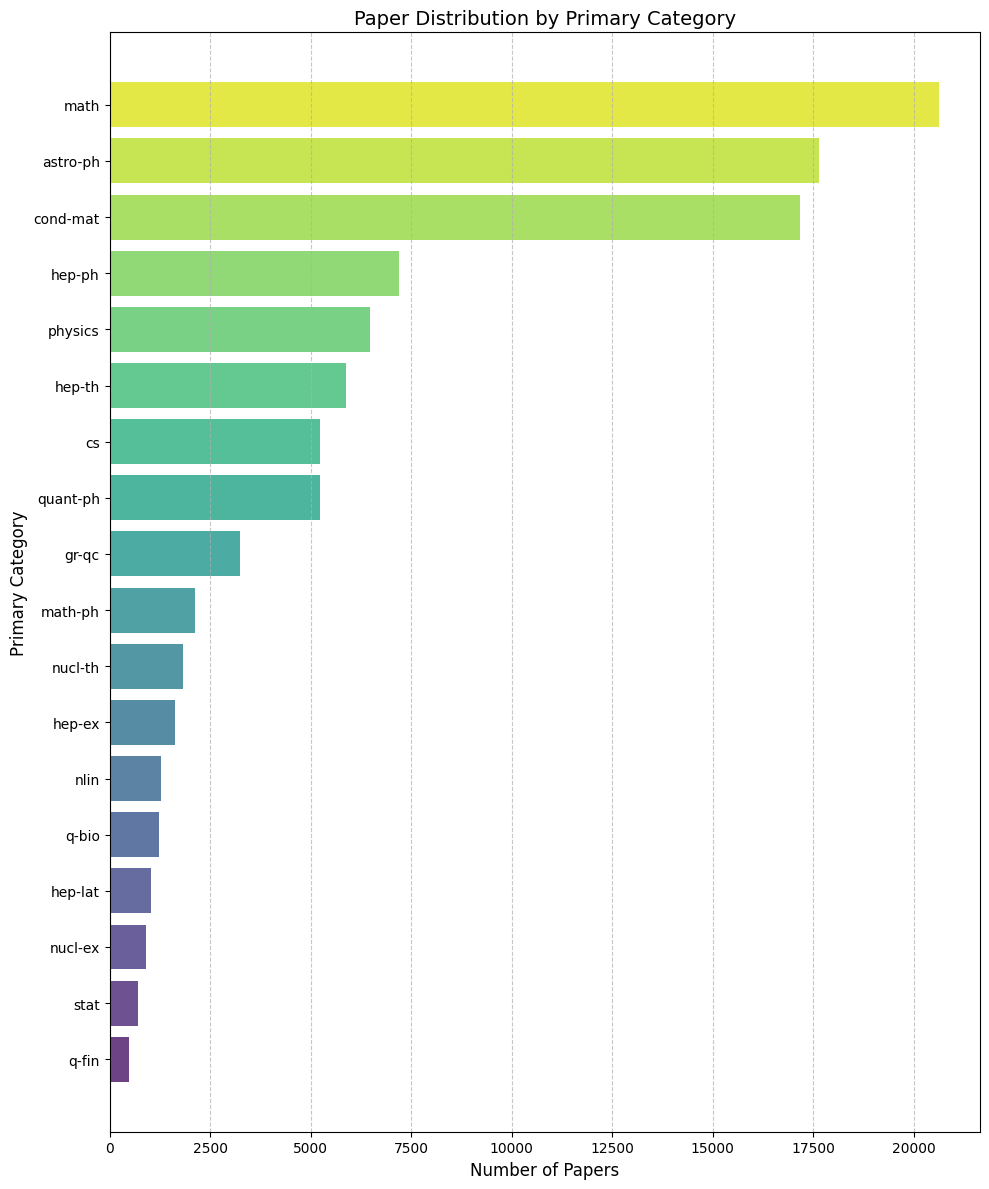

In [ ]:
# Visualise primary category sizes - we see that the distribution is very uneven

# Count papers per primary category, sorted descending
cat_counts = df['primary_category'].value_counts().sort_values(ascending=True)

# Figure
plt.figure(figsize=(10,12))  # tall figure for all categories

# Horizontal bar plot with color gradient
colors = sns.color_palette("viridis", n_colors=len(cat_counts))
plt.barh(cat_counts.index, cat_counts.values, color=colors, alpha=0.8)

# Add grid lines
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Labels and title
plt.xlabel("Number of Papers", fontsize=12)
plt.ylabel("Primary Category", fontsize=12)
plt.title("Paper Distribution by Primary Category", fontsize=14)

plt.tight_layout()
plt.show()

**2. Data Preprocessing**

In [ ]:
# Since we found earlier that the dataset has too short abstracts, now we need #    to find a cutoff point for removal of too short outliers with
#    uninformative abstracts.
# This is done via qualitative evaluation of three short abstracts categories:
#    1. Length up to 10 words; 2. 10-20 words; 3. 20-30 words.

# Function to count words
def word_count(text):
    return len(text.split())

# Counters for each range
counts = {'up_to_10':0, '11_20':0, '21_30':0}

# Lists to store results
results = {'up_to_10':[], '11_20':[], '21_30':[]}

# Iterate through abstracts once
for _, row in df.iterrows():
    wc = word_count(row['abstract'])
    if wc <= 10 and counts['up_to_10'] < 10:
        results['up_to_10'].append(row)
        counts['up_to_10'] += 1
    elif 11 <= wc <= 20 and counts['11_20'] < 10:
        results['11_20'].append(row)
        counts['11_20'] += 1
    elif 21 <= wc <= 30 and counts['21_30'] < 10:
        results['21_30'].append(row)
        counts['21_30'] += 1
    # Stop if all ranges have 10
    if all(c==10 for c in counts.values()):
        break

# Display results
for key in ['up_to_10','11_20','21_30']:
    print(f"=== Abstracts {key.replace('_','-')} words ===")
    display(pd.DataFrame(results[key])[['abstract','categories']])

=== Abstracts up-to-10 words ===


,abstract,categories
155,This paper has been withdrawn by the authors.\n,astro-ph
373,This paper has been withdrawn due to copyrig...,physics.geo-ph
378,This paper visualizes a knot reduction algor...,cond-mat.soft cond-mat.stat-mech
921,We prove a variation of Gronwall's lemma.\n,math.CA
1012,A remark on a paper by Birkar-Cascini-Hacon-...,math.AG
1013,A simple application of the semipositivity.\n,math.AG
1060,Comment on ``Chiral Suppression of Scalar Gl...,hep-ph hep-ex
1615,"Reply to the comment of Chao, He, and Ma.\n",hep-ph
2143,The proof of proposition 3.6 is not correct\n,math.AC math.AG
2638,Withdrawn due to an incompleteness of the ma...,math.SG math.GT


=== Abstracts 11-20 words ===


,abstract,categories
33,This is a supplement to the paper arXiv:q-bi...,q-bio.PE q-bio.CB quant-ph
70,No abstract given; compares pairs of languag...,physics.soc-ph
107,Description of a polynomial time reduction o...,cs.CC
280,An critical overview of the current state of...,astro-ph
285,The paper presents a survey of mathematical ...,math.AP math-ph math.MP
479,paper withdrawn due to the possible error in...,cond-mat.mes-hall
746,In this paper we consider successive iterati...,math.DG math.CA
1040,We study asymptotics of various Euclidean ge...,math.MG
1079,This paper has been withdrawn by the author ...,quant-ph
1202,This paper had been withdrawn because the pr...,hep-lat hep-ph


=== Abstracts 21-30 words ===


,abstract,categories
13,In this article we discuss a relation betwee...,math.CA math.AT
18,In this note we give a new method for gettin...,math.PR math.AG
100,In this contribution we go through the devel...,hep-th
101,We prove a duality theorem for certain grade...,math.AC math.AG
123,We prove the existence of global Bishop disc...,math.CV
230,We provide a description of the interpolatin...,math.CV
235,We prove that the limit hypersurfaces of con...,math.DG
314,We lead the algorithm of expansion of sojour...,math.PR math.AP
347,1 Generalities\n 2 Empirical diagnostics ba...,astro-ph
389,We study the notion of Fagnano orbits for du...,math.DS


In [ ]:
# As seen above, abstracts of length 0-20 words often have issues in the content
# Therefore, we will drop all abstracts under 21 words from our dataset

df = df[df['abstract'].apply(lambda x: len(x.split()) > 20)]

print(f"Number of abstracts after dropping short ones: {len(df)}")
print(f"Number of unique primary categories after dropping short abstracts: {df['primary_category'].nunique()}")
print(f"Number of unique full categories after dropping short abstracts: {df['categories'].nunique()}")

Number of abstracts after dropping short ones: 98611
Number of unique primary categories after dropping short abstracts: 18
Number of unique full categories after dropping short abstracts: 6031


In [ ]:
# Next, we will drop duplicates as arXiv sometimes has cross-listings

df = df.drop_duplicates(subset='abstract')

print(f"Number of abstracts after dropping duplicates: {len(df)}")
print(f"Number of unique primary categories after dropping duplicates: {df['primary_category'].nunique()}")
print(f"Number of unique full categories after dropping duplicates: {df['categories'].nunique()}")

Number of abstracts after dropping duplicates: 98556
Number of unique primary categories after dropping duplicates: 18
Number of unique full categories after dropping duplicates: 6030


In [ ]:
# Finally, we will clean whitespaces and remove LaTeX equations and citations
# We do not perform lowercasing as BERT embeddings can be case-aware
# We also do not trim long abstracts or tokenize as it can be taken care of by
#   HF tokenizer in the modeling step.

def clean_text(text):
    text = re.sub(r'\s+', ' ', text)  # normalize whitespace
    text = re.sub(r'\$\$.*?\$\$', '', text)  # remove LaTeX equations
    text = re.sub(r'\[.*?\]', '', text)      # remove bracketed citations
    return text.strip()

df['abstract'] = df['abstract'].apply(clean_text)

In [ ]:
# No lowercasing, lemmatization or stopword removal was performed here since
#   SBERT embeddings capture semantic meaning from full sentence context well.

**3. BERTopic Model Fitting with Hyperparameter Tuning**

GPU usage is recommended for this block.

In [ ]:
# Split data to 70% train, 15% test and 15% validate sets
#   with stratification by primary category to ensure equal
#   category representation across the datasets.

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['primary_category']  # ensures proportional representation
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['primary_category']
)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

Train: 68989, Validation: 14783, Test: 14784


In [ ]:
# Load SBERT embedding model - this model was chosen as the most lightweight
#   option with acceptable performance level
sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')

def compute_embeddings_gpu(texts, batch_size=1024):
    """
    Compute embeddings for a list of texts on GPU.
    Clears CUDA cache after each batch to avoid memory issues.
    Returns a numpy array of shape (num_texts, embedding_dim)
    """
    embeddings_list = []

    n_texts = len(texts)
    for start_idx in range(0, n_texts, batch_size):
        end_idx = min(start_idx + batch_size, n_texts)
        batch_texts = texts[start_idx:end_idx]

        # Compute embeddings for this batch
        batch_embeddings = sbert_model.encode(batch_texts, show_progress_bar=True, device='cuda', batch_size=128)
        embeddings_list.append(batch_embeddings)

        # Clear GPU cache after each batch
        torch.cuda.empty_cache()

    # Combine all batches into one array
    embeddings = np.vstack(embeddings_list).astype(np.float32)
    return embeddings

train_texts = train_df['abstract'].tolist()
val_texts   = val_df['abstract'].tolist()
test_texts  = test_df['abstract'].tolist()

print("Computing train embeddings on GPU...")
train_embeddings = compute_embeddings_gpu(train_texts)
np.save('train_embeddings.npy', train_embeddings)

print("Computing validation embeddings on GPU...")
val_embeddings = compute_embeddings_gpu(val_texts)
np.save('val_embeddings.npy', val_embeddings)

print("Computing test embeddings on GPU...")
test_embeddings = compute_embeddings_gpu(test_texts)
np.save('test_embeddings.npy', test_embeddings)

print("All embeddings computed and saved successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

All embeddings computed and saved successfully!


In [ ]:
train_embeddings = np.load('train_embeddings.npy', mmap_mode='r')
val_embeddings = np.load('val_embeddings.npy', mmap_mode='r')
test_embeddings = np.load('test_embeddings.npy', mmap_mode='r')

In [ ]:
# Fit the model and perform hyperparameter search, focusing on key metrics
#   contributing to clustering quality (n_neighbors which will regulate the
#   amount of dimensionality reduction via UMAP and min_cluster_size which will
#   control the number of data points per cluster)
# We also check if reducing the number of topics (i.e. forcing for smaller,
#   similar clusters to be merged togehter) improves the performance,
#   evaluated via Normalized Mutual Information (NMI) score against ground
#   truth primary categories from the arXiv dataset

In [ ]:
train_embeddings = train_embeddings.astype(np.float32)
val_embeddings = val_embeddings.astype(np.float32)

train_docs = train_df['abstract'].tolist()
val_docs = val_df['abstract'].tolist()
val_labels = val_df['primary_category'].tolist()

# -------------------------------
# Hyperparameter grid
# -------------------------------
min_cluster_sizes = [50, 500, 750, 1000]
n_neighbors_list = [30, 50, 100]

best_model = None
best_nmi = -1
best_params = None

results = []

print("Starting BERTopic grid search...")

# -------------------------------
# Grid search
# -------------------------------
for mcs in min_cluster_sizes:
    for nn in n_neighbors_list:
        print(f"\nTesting min_cluster_size={mcs}, n_neighbors={nn}")

        # UMAP
        umap_model = UMAP(
            n_neighbors=nn,
            n_components=5,
            metric='cosine',
            random_state=42,
            low_memory=True
        )

        # HDBSCAN
        hdbscan_model = HDBSCAN(
            min_cluster_size=mcs,
            metric='euclidean',
            prediction_data=True
        )

        # BERTopic
        topic_model = BERTopic(
            embedding_model=None,
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            calculate_probabilities=False,
            low_memory=True,
            verbose=False
        )

        # -------------------------------
        # Fit model
        # -------------------------------
        topics, _ = topic_model.fit_transform(
            documents=train_docs,
            embeddings=train_embeddings
        )

        # -------------------------------
        # Validation
        # -------------------------------
        val_topics, _ = topic_model.transform(
            documents=val_docs,
            embeddings=val_embeddings
        )

        nmi = NMI(val_labels, val_topics)

        n_clusters = len(set(topics)) - (1 if -1 in topics else 0)
        outlier_frac = np.mean(np.array(topics) == -1)

        print(f" -> NMI={nmi:.3f}, clusters={n_clusters}, outliers={outlier_frac:.2%}")

        # Store results
        results.append({
            "min_cluster_size": mcs,
            "n_neighbors": nn,
            "nmi": nmi,
            "n_clusters": n_clusters,
            "outlier_frac": outlier_frac
        })

        # Track best model
        if nmi > best_nmi:
            best_nmi = nmi
            best_model = topic_model
            best_params = {'min_cluster_size': mcs, 'n_neighbors': nn}

        # -------------------------------
        # Cleanup
        # -------------------------------
        del topics, val_topics
        del topic_model
        gc.collect()
        torch.cuda.empty_cache()

# -------------------------------
# Final best model info
# -------------------------------
print("\n==============================")
print(f"Best params: {best_params}")
print(f"Best NMI: {best_nmi:.3f}")

final_clusters = len(best_model.get_topics()) - 1
print(f"Final number of clusters: {final_clusters}")

best_model.save("best_bertopic_model")
print("Model saved!")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Starting BERTopic grid search...

Testing min_cluster_size=50, n_neighbors=30
 -> NMI=0.004, clusters=2, outliers=0.12%

Testing min_cluster_size=50, n_neighbors=50
 -> NMI=0.358, clusters=67, outliers=36.63%

Testing min_cluster_size=50, n_neighbors=100
 -> NMI=0.356, clusters=63, outliers=37.62%

Testing min_cluster_size=500, n_neighbors=30
 -> NMI=0.415, clusters=3, outliers=9.99%

Testing min_cluster_size=500, n_neighbors=50
 -> NMI=0.470, clusters=4, outliers=12.45%

Testing min_cluster_size=500, n_neighbors=100
 -> NMI=0.454, clusters=4, outliers=10.40%

Testing min_cluster_size=750, n_neighbors=30
 -> NMI=0.482, clusters=7, outliers=28.51%

Testing min_cluster_size=750, n_neighbors=50
 -> NMI=0.504, clusters=5, outliers=13.45%

Testing min_cluster_size=750, n_neighbors=100
 -> NMI=0.452, clusters=4, outliers=10.69%

Testing min_cluster_size=1000, n_neighbors=30
 -> NMI=0.449, clusters=4, outliers=12.10%

Testing min_cluster_size=1000, n_neighbors=50
 -> NMI=0.460, clusters=4, ou

2026-03-29 14:38:51,908 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


 -> NMI=0.450, clusters=4, outliers=11.34%

Best params: {'min_cluster_size': 750, 'n_neighbors': 50}
Best NMI: 0.504
Final number of clusters: 5
Model saved!


In [ ]:
best_model = BERTopic.load("best_bertopic_model")

In [ ]:
# Plotting the grid search results to compare different options and ensure the
#   selected model was high-performing and found an optimal number of clusters

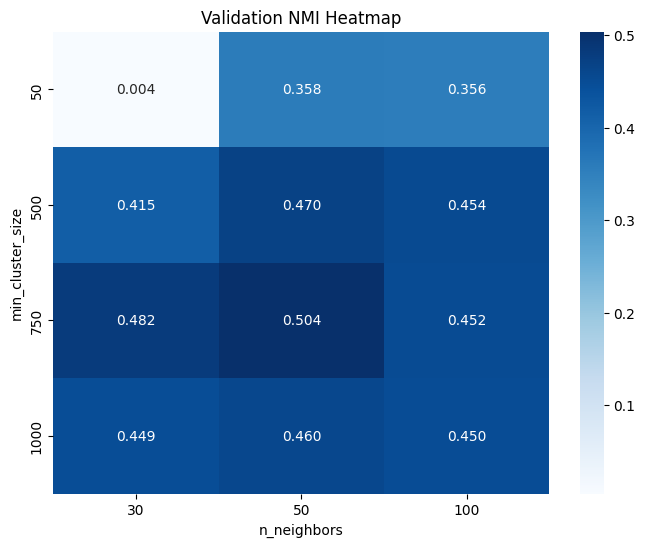

In [ ]:
# Pivot table: rows = min_cluster_size, columns = n_neighbors, values = NMI
heatmap_df = results_df.pivot_table(
    index="min_cluster_size",
    columns="n_neighbors",
    values="nmi"
)

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="Blues")
plt.title("Validation NMI Heatmap")
plt.xlabel("n_neighbors")
plt.ylabel("min_cluster_size")
plt.show()

In [ ]:
# As a result of hyperparameter tuning, the model with min_cluster_size=750 and #   n_neighbors=50 had the highest NMI (0.504)

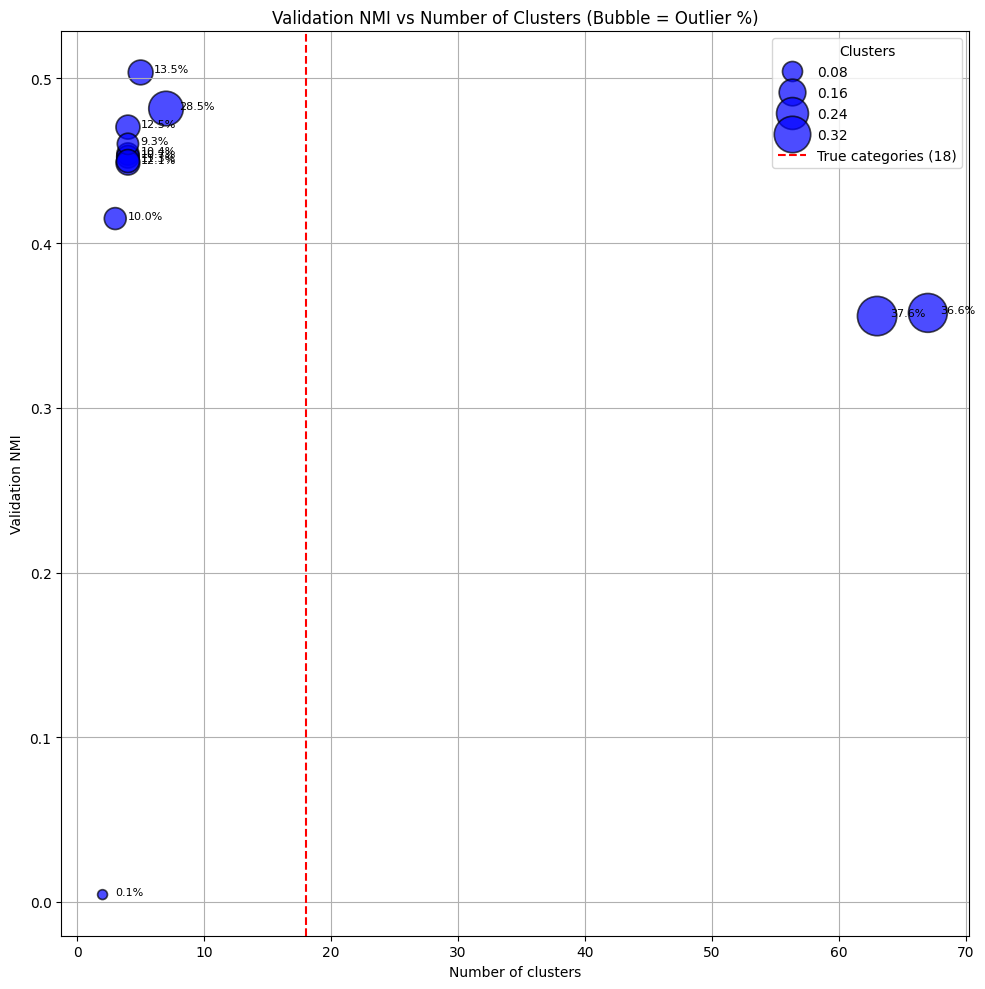

In [ ]:
# -------------------------------------------------
# Create DataFrame for grid search results plotting
# -------------------------------------------------
results_df = pd.DataFrame(results)

plt.figure(figsize=(10,10))

# Bubble plot: x = #clusters, y = NMI, bubble = outlier %
sns.scatterplot(
    data=results_df,
    x="n_clusters",
    y="nmi",
    size="outlier_frac",
    sizes=(50, 800),
    alpha=0.7,
    color="blue",
    edgecolor="black"
)

# Annotate with outlier %
for _, row in results_df.iterrows():
    plt.text(
        row["n_clusters"] + 1,
        row["nmi"],
        f"{row['outlier_frac']*100:.1f}%",
        fontsize=8
    )

# Reference line for true number of categories
plt.axvline(18, color='red', linestyle='--', label='True categories (18)')

plt.title("Validation NMI vs Number of Clusters (Bubble = Outlier %)")
plt.xlabel("Number of clusters")
plt.ylabel("Validation NMI")
plt.grid(True)
plt.legend(title="Clusters")
plt.tight_layout()
plt.show()

In [ ]:
# As seen above, the better performing models all found <10 clusters,
#   meaning this is the optimal number of clusters for the 100K papers dataset.

**4. Final Evaluation on the Holdout Set**

In [ ]:
# Evaluating the model on the holdout set to get final metrics for the report
#   and ensure the number of clusters found aligns well with the categories
#   in the arXiv dataset

In [ ]:
# -------------------------------
# Transform test embeddings
# -------------------------------
test_topics, _ = best_model.transform(
    documents=test_df['abstract'].tolist(),
    embeddings=test_embeddings
)

# Ground-truth labels
test_labels = test_df['primary_category'].tolist()

# -------------------------------
# Evaluation metrics
# -------------------------------
nmi_score = normalized_mutual_info_score(test_labels, test_topics)
ari_score = adjusted_rand_score(test_labels, test_topics)
fmi_score = fowlkes_mallows_score(test_labels, test_topics)

# Silhouette score
umap_embeddings = best_model.umap_model.transform(test_embeddings)
test_topics_arr = np.array(test_topics)
mask = test_topics_arr != -1
filtered_topics = test_topics_arr[mask]
filtered_umap_embeddings = umap_embeddings[mask]
sil_score = silhouette_score(filtered_umap_embeddings, filtered_topics)

# -------------------------------
# Report results
# -------------------------------
print(f"Final evaluation on unseen test set:")
print(f" - NMI: {nmi_score:.3f}")
print(f" - ARI: {ari_score:.3f}")
print(f" - FMI: {fmi_score:.3f}")
print(f" - Silhouette: {sil_score:.3f}")

Final evaluation on unseen test set:
 - NMI: 0.500
 - ARI: 0.435
 - FMI: 0.532
 - Silhouette: 0.498


**5. Visualising Clusters for Qualitative Analysis**

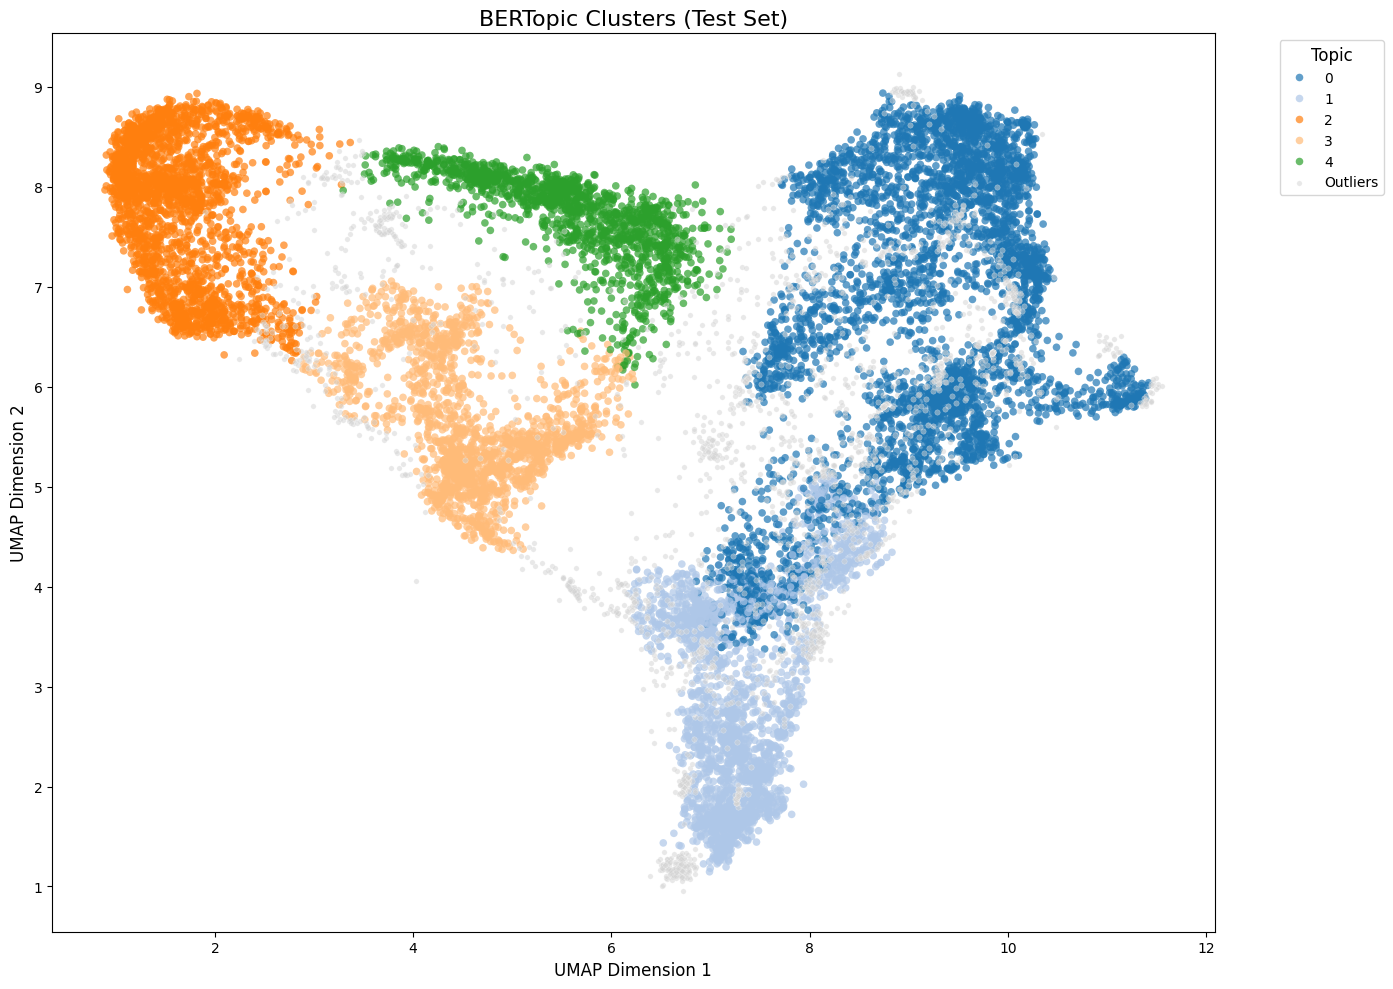

In [ ]:
# -------------------------------
# Project test embeddings to 2D using trained BERTopic UMAP
# -------------------------------
embedding_2d = best_model.umap_model.transform(test_embeddings)

# -------------------------------
# Prepare dataframe for plotting
# -------------------------------
plot_df = pd.DataFrame({
    'x': embedding_2d[:,0],
    'y': embedding_2d[:,1],
    'topic': test_topics,
})

# Separate outliers (-1) for clearer visualization
outliers_df = plot_df[plot_df['topic'] == -1]
inliers_df = plot_df[plot_df['topic'] != -1]

# -------------------------------
# Plot clusters
# -------------------------------
plt.figure(figsize=(14,10))

# Plot inliers first
sns.scatterplot(
    data=inliers_df,
    x='x', y='y',
    hue='topic',
    palette='tab20',
    legend='full',
    alpha=0.7,
    edgecolor='none',
    s=30
)

# Plot outliers on top, with gray color
if len(outliers_df) > 0:
    sns.scatterplot(
        data=outliers_df,
        x='x', y='y',
        color='lightgray',
        alpha=0.5,
        label='Outliers',
        s=15
    )

plt.title("BERTopic Clusters (Test Set)", fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

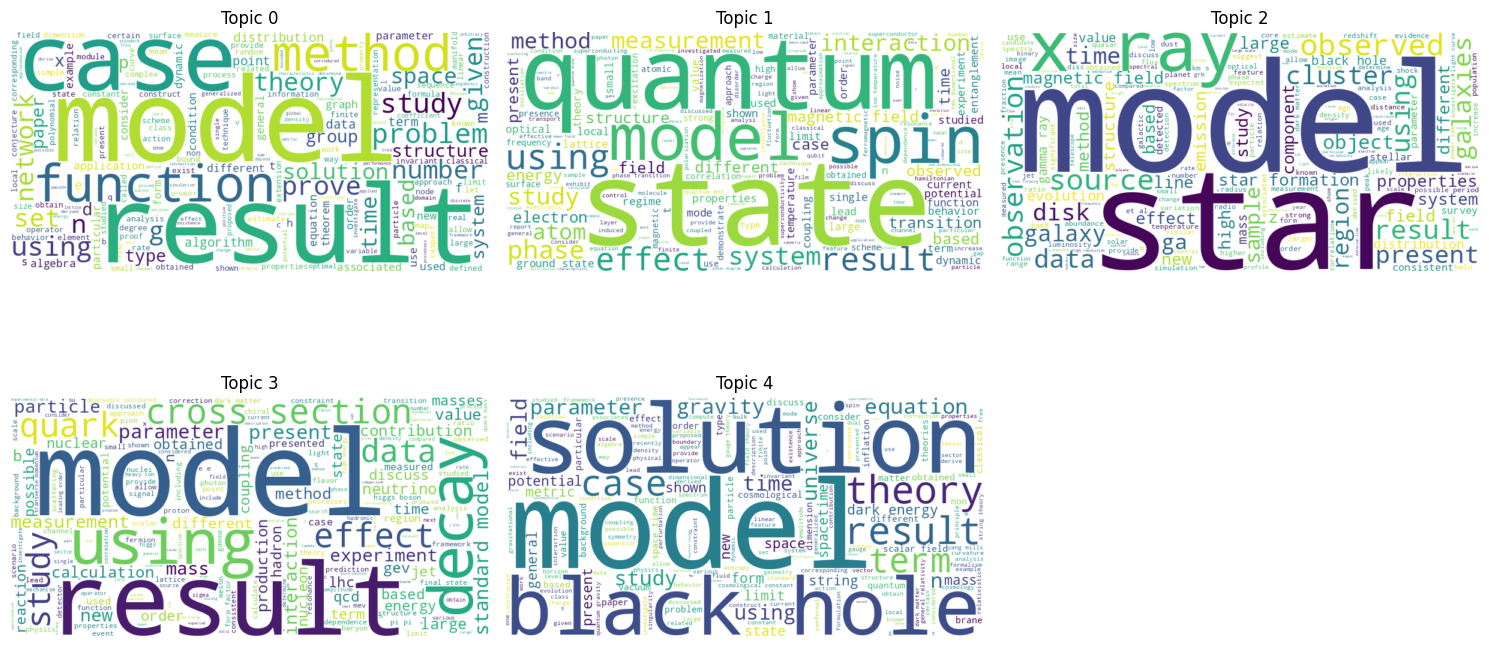

In [ ]:
# -------------------------------
# Function to remove stopwords
# -------------------------------
def remove_stopwords(texts):
    stopwords = ENGLISH_STOP_WORDS
    cleaned = []
    for t in texts:
        tokens = [w for w in t.lower().split() if w not in stopwords]
        cleaned.append(" ".join(tokens))
    return cleaned

# -------------------------------
# Clean test abstracts
# -------------------------------
test_texts_clean = remove_stopwords(test_df['abstract'].tolist())

# -------------------------------
# Generate word clouds for all topics
# -------------------------------
unique_topics = sorted([t for t in np.unique(test_topics) if t != -1])
n_topics = len(unique_topics)
cols = 3  # number of columns in the grid
rows = math.ceil(n_topics / cols)

plt.figure(figsize=(cols*5, rows*4))

for i, topic_id in enumerate(unique_topics):
    # Collect all texts for this topic
    topic_texts = [txt for txt, t in zip(test_texts_clean, test_topics) if t == topic_id]
    all_text = " ".join(topic_texts)

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(all_text)

    plt.subplot(rows, cols, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Topic {topic_id}", fontsize=12)

plt.tight_layout()
plt.show()

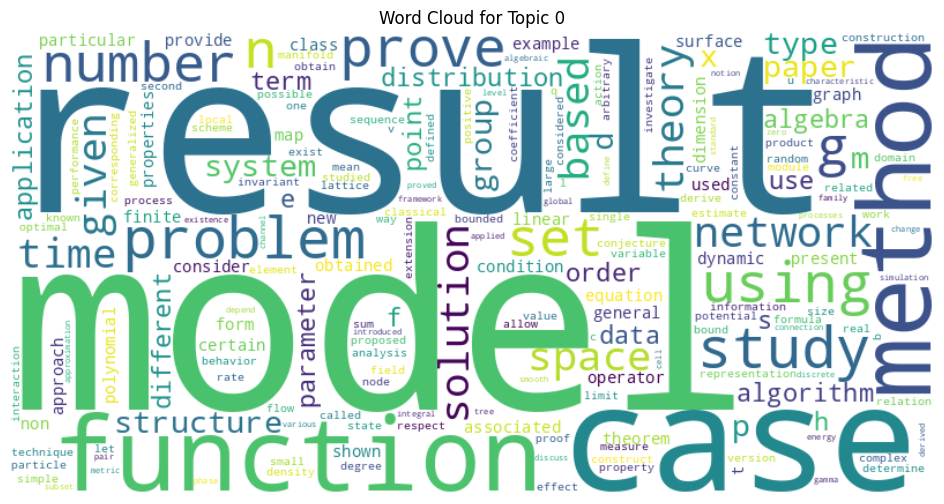

In [ ]:
topic_id = 0  # pick a topic
topic_texts = [txt for txt, t in zip(test_texts_clean, test_topics) if t == topic_id]

all_text = " ".join(topic_texts)
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title(f"Word Cloud for Topic {topic_id}")
plt.show()

In [ ]:
# The model successfully found key themes in the dataset, though potentially
#   missed a few of the lesser represented categories, grouping them as outliers